In [22]:
#first we read the dataset file that we have
import pandas as pd
df = pd.read_csv('Updated_sales.csv')
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


In [23]:
#from the previous output I noticed that there is a whole row with null all over so I decided to drop nulls
df.dropna(inplace=True)
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001"


In [24]:
# to check the types are correct
df.dtypes

,0
Order ID,object
Product,object
Quantity Ordered,object
Price Each,object
Order Date,object
Purchase Address,object


In [25]:
#noticed that some types are not correct so I will convert them and chack their types
df['Quantity Ordered'] = pd.to_numeric(df['Quantity Ordered'],errors='coerce')
df['Price Each'] = pd.to_numeric(df['Price Each'], errors='coerce')
df['Order Date'] = pd.to_datetime(df['Order Date'],errors='coerce')
df.dtypes

/tmp/ipython-input-25-669536910.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order Date'] = pd.to_datetime(df['Order Date'],errors='coerce')


,0
Order ID,object
Product,object
Quantity Ordered,float64
Price Each,float64
Order Date,datetime64[ns]
Purchase Address,object


In [26]:
#noticed that the quantity is float while it should be integer so i will convert them again
#since i did errors='coerce' this means it filled the things that couldn't convert it in the previous cell with null
#so i needed to drop the new nulls so i can convert it to int
df.dropna(subset=['Quantity Ordered'], inplace=True)
df['Quantity Ordered'] = df['Quantity Ordered'].astype(int)
df.dtypes

,0
Order ID,object
Product,object
Quantity Ordered,int64
Price Each,float64
Order Date,datetime64[ns]
Purchase Address,object


In [27]:
# these are the top 10 products ordered, to get a better grasp at what are the most vital products to be in stock
df.groupby('Product')['Quantity Ordered'].sum().sort_values(ascending=False).head(10)

,Quantity Ordered
Product,
AAA Batteries (4-pack),4955
AA Batteries (4-pack),4648
Lightning Charging Cable,3812
USB-C Charging Cable,3732
Wired Headphones,3356
Apple Airpods Headphones,2535
Bose SoundSport Headphones,2168
27in FHD Monitor,1229
iPhone,1133


In [28]:
#here i wanted to get the city but only had the addres so i noticed that i could get the city by accesing the second element seperated by a comma
#split will split the whole thing every time it sees a comma after i'll take the second element[1] i'll take it by strip
df['City'] = df['Purchase Address'].apply(lambda x: x.split(',')[1].strip())
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,City
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",Dallas
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",Boston
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",Los Angeles
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",Los Angeles
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",Los Angeles


In [29]:
# now we can get the top 10 ordering cities, so the campaigns we do and expansion would reflect this
df.groupby('City')['Quantity Ordered'].sum().sort_values(ascending=False).head(10)

,Quantity Ordered
City,
San Francisco,8179
Los Angeles,5471
New York City,4545
Boston,3599
Seattle,2756
Atlanta,2686
Dallas,2621
Portland,2326
Austin,1827


In [55]:
# we will make a profit column with some easy math and get the count of each profit point
# to see if there is a trend
df['profit'] = df['Quantity Ordered'] * df['Price Each']
df['profit'].value_counts().head(10)

,count
profit,
14.95,3314
11.95,3142
11.99,2834
3.84,2517
150.00,2495
2.99,2231
99.99,2134
149.99,1211
600.00,1170


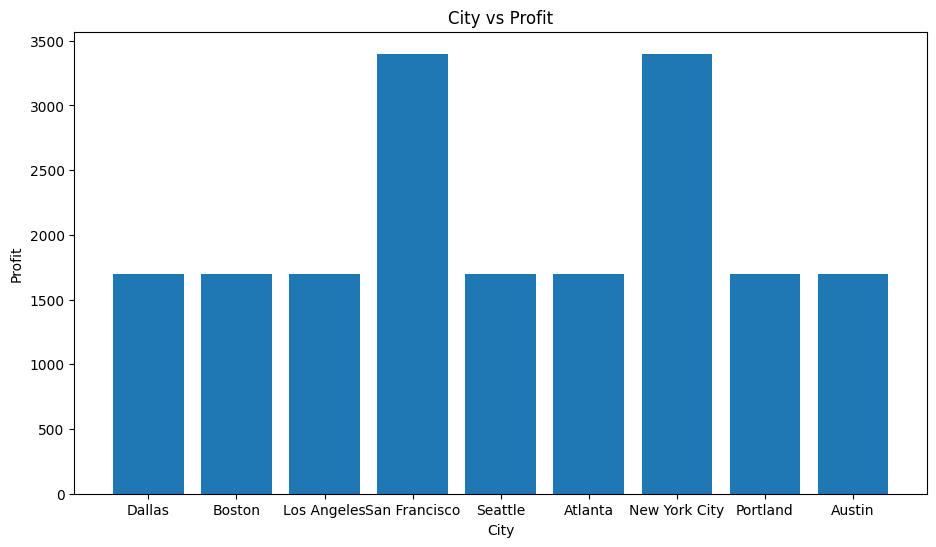

In [60]:
plt.figure(figsize=(11, 6))
plt.bar(df['City'],df['profit'])
plt.xlabel('City')
plt.ylabel('Profit')
plt.title('City vs Profit')
plt.show()

While most cities deliver similar profit levels, San Francisco and New York City stand out with significantly higher returns. This suggests we should prioritize these two markets for targeted expansion and tailored growth initiatives.

In [52]:
#seperate them into equal group to prepare them for plotting although not that functional i decided to go with it
price_bins = pd.cut(df['Price Each'], bins=2, labels=['low', 'high'])
df['Price Category'] = price_bins

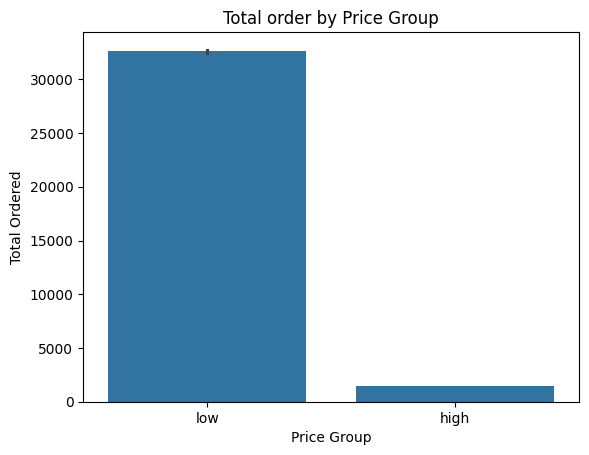

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.barplot( x ='Price Category',y ='Quantity Ordered', data = df , estimator=sum)
plt.title('Total order by Price Group')
plt.xlabel('Price Group')
plt.ylabel('Total Ordered')
plt.show()

the low priced group was the dominant group in terms of quantity ordered, which indicates that people are urging for low priced items which shows a great place to opportunity to tackle this with coupons and offers

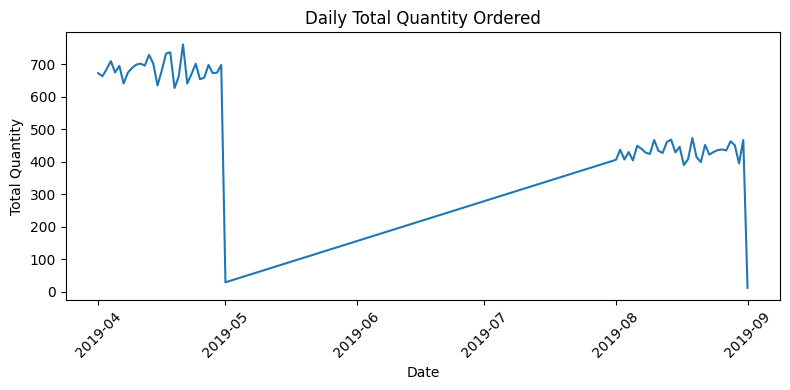

In [56]:
daily_sales = df.groupby(df['Order Date'].dt.date)['Quantity Ordered'].sum()

daily_sales.plot(kind='line', figsize=(8,4), title='Daily Total Quantity Ordered')
plt.xlabel('Date'); plt.ylabel('Total Quantity'); plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

We can clearly see that order volumes dropped sharply after April. We should investigate what caused the downturn and compare it to the strategies we had in place beforehand, when sales were skyrocketing.